In [140]:
import dotenv, os
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from langchain_openai import ChatOpenAI
import operator
from typing import Dict, List, Annotated, Literal
from tavily import TavilyClient
from langchain_community.tools import DuckDuckGoSearchResults, TavilySearchResults



In [141]:
dotenv.load_dotenv()

True

In [142]:
# step1: Define the base LLM
base_llm = ChatOpenAI(model='gpt-4.1-mini', temperature=0.0, max_tokens=4000, request_timeout=120)

In [143]:
# Step 2: Define the SupervisorDecision model
class SupervisorDecision(BaseModel):
    """ Supervisor's routing decision - Must pick one of these options """
    next_agent : Literal['researcher', 'mathematician', 'final'] = Field(description = "Which worker shouldwork next or 'final' if enough information is gathered to produce the final answer.")

    reason : str = Field(description = "Reasoning behind the decision. This will be used to explain the decision to the user.")


In [144]:
# Step 3: Define the FinalAnswer model
class FinalAnswer(BaseModel):
    """ Final answer model """
    answer : str = Field(description = "Final answer to the user's question.")


# Math extractor 
class Math_string_extractor(BaseModel):
    """Extract Exact Mathametical Expresion from a String"""
    math_string : str = Field(description="Extract eaxact mathmetical expresion for calculation")

In [145]:
# Supervisor State

class SupervisorState(TypedDict):
    query: str
    history: Annotated[list, operator.add]
    final_answer: str

In [146]:
# Define the tools which will work inside of the worker nodes

# Calculator tool

def calculate(expression : str) -> str:
    """ Simple calculator tool that evaluates a mathematical expression. """
    try:
        return str(
            eval(expression, 
                 {"__builtins__": {}},
                   {}))
    except Exception as e:
        return f"Error: {e}"           # ← Galat expression ho toh error pakdo!

print("Calcualte is working")
print(f"Result: {calculate('25 * 4')}")



# Search Tool 
tavily_key= os.environ.get("TAVILY_API_KEY")
tavily_tool = TavilySearchResults( search_kwargs={"num_results": 2})

def web_search(query: str)-> str:
    """ Simple web search with Tavily tool"""

    output=[]

    try:
        search_result = tavily_tool.invoke(query)


        for i in search_result:


            output.append(f" Title : {i.get('title', 'No title')}")
            output.append(f" Content : {i.get('content', 'No snippet')}")
            output.append(f" URL : {i.get('url', 'No link')}")
    except Exception as e:
        print(f"Error {e}")

    if output:
        return "\n".join(output)
    


print("Web search is working")
print(web_search("What is the GDP of Inidan in 2026"))





Calcualte is working
Result: 100
Web search is working
 Title : India GDP (2026) - Worldometer
 Content : # Image 2: Flag of India

India GDP (2026)

### IMF (2026)

Nominal (current) Gross Domestic Product (GDP) of India is$4.15 trillion($4,153,191,000,000)as of 2026,according to the International Monetary Fund (IMF).The GDP growth rate in 2026 is6.5%, according to the International Monetary Fund (IMF).GDP per Capita in India (with a population of 1,476,625,576 people)is$2,813 in 2026,an increase of$137 from $2,675 in 2025; this represents a change of 5.1%in GDP per capita. [...] ## India GDP Projections (IMF)

 Nominal GDP  PPP GDP 

| Year | GDP Nominal (Current USD) | GDP Growth | GDP per capita | Pop. Change |
 ---  --- 
| 2027 | $4,579,083,000,000 | 6.5% | $3,075 | 0.85% |
| 2028 | $5,058,754,000,000 | 6.5% | $3,369 | 0.82% |
| 2029 | $5,599,432,000,000 | 6.5% | $3,700 | 0.8% |
| 2030 | $6,173,385,000,000 | 6.5% | $4,048 | 0.77% |
| 2031 | $6,792,432,000,000 | 6.5% | $4,421 | 0.7

In [147]:
# Supervisor node

def supervisor_node(state: SupervisorState)->Command[Literal['researcher', 'mathematician', 'final']]:



# Done so far variable will have all the history what happned yet inside the application, like which worker worked if any web search result is generated then if the generated result is fine to give the answer etc

    done_so_far = "\n".join(
        state.get('history', [])
    ) or "Nothing Yet"


    struct_llm = base_llm.with_structured_output(SupervisorDecision)

    query = state['query']

    prompt = f""" 
                You are a supervisor manngaing 2 workers.\n

                - "researcher" : does a web search for the query asked by the user and gets the relavent part - recent news, upadted, flactual updates etc \n

                - "mathematician" : Dose calculation \n

            
                "Original Query" :\n {query}\n

                "Work completed so far" : \n 
                {done_so_far}\n


                Decide what should happen next. If you have enough infomration from worker done so far, for full answer of the original query choose 'final' 
            """
    
    decision : SupervisorDecision = struct_llm.invoke(prompt)

    print(f"🕴️Supervior - > Goto {decision.next_agent} | Resason {decision.reason}")
    
    

    return Command(
        goto=decision.next_agent, 
        update = {'history': [f'[Supervisor] decided to go {decision.next_agent} because of {decision.reason}']}
    )

In [150]:
#step 6 Worker Node

def research_node(state: SupervisorState)-> Command[Literal["supervisor"]]:
    print("🔎 Researcher Is working")

    result = web_search(state['query'])
    # print(result)

    return Command(
        goto='supervisor',
        update={'history': [
            f"[Researcher] {result}"
        ]}
    )


def math_node(state: SupervisorState)-> Command[Literal["supervisor"]]:
    print("📱 Mathametician is Working")


    extractor_exact_math_string = base_llm.with_structured_output(Math_string_extractor)

    prompt =f"""You are a Mathametical Expresion extractor. You need to provide the extracted result in a string from the given query

    Example : \n
    "What is the value of 10+20? -> '10 + 20'
    "What is the gdp of inid and what is 10*20? -> "10 * 20"

    Query: \n 
    {state['query']}

        """

    math_string = extractor_exact_math_string.invoke(prompt)





    result = calculate(math_string.math_string)


    return Command(
        goto='supervisor',
        update={'history': [
            f"[Mathameticain] {result}"
        ]}
    )

In [151]:
# Step 7 : Final Node

def final_node(state: SupervisorState)-> Command[Literal["__end__"]]:
    print("✍️ Generating Result")

    done_so_far = "\n".join(state['history'])

    final_llm_struct= base_llm.with_structured_output(FinalAnswer)

    prompt = f""" 

    Orginal Query : \n {state['query']} \n

    Work Compeleted : \n
    {done_so_far}

    Write the final answer for the user
    

    Rule:
    - Each sentence should have a relevant and consicutive crsip answer
    - 2 diffrent type of answers should not be in a single line (Example : - India's GDP in 2025 (URL: metion the url if any) : X.X Mn $ \n - 10 + 20 = 30)
    - Never ever say which workers has worked 
    
            """

    result : FinalAnswer = final_llm_struct.invoke(prompt)
    print(result.answer)

    return Command(
        goto=END, 
        update={'final_answer': result.answer}
    )



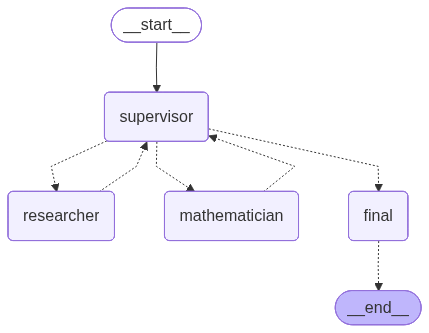

In [152]:
# Step 8 : Graph Building 


builder = StateGraph(SupervisorState)


# Node Addition
builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher", research_node)
builder.add_node("mathematician", math_node)
builder.add_node("final", final_node)


# Edge

builder.add_edge(START, "supervisor" )


#app 

app = builder.compile()
app 





In [153]:
initial_state = {'query': "What is 10+20? and what is the current situation of westbengal in the term of political aspect", 'history':[]}

In [154]:
app_result=app.invoke(initial_state)

🕴️Supervior - > Goto researcher | Resason The query has two parts: a simple arithmetic calculation and a request for the current political situation in West Bengal. Since no work has been done yet, the researcher should first gather updated and relevant information about the political situation in West Bengal. The mathematician can then handle the calculation part once the political information is obtained or simultaneously, but starting with the researcher is logical to get the factual updates first.
🔎 Researcher Is working
🕴️Supervior - > Goto mathematician | Resason The researcher has provided comprehensive and up-to-date information about the political situation in West Bengal. The only remaining part of the user's query is the simple arithmetic calculation '10+20'. This can be handled by the mathematician to complete the full answer.
📱 Mathametician is Working
🕴️Supervior - > Goto final | Resason The researcher has provided detailed and current information about the political situ

In [157]:
print(app_result['final_answer'])

10 + 20 = 30.

As of 2026, West Bengal is governed by the Bharatiya Janata Party (BJP), which won a significant victory in the 2026 West Bengal Legislative Assembly election, ending the 15-year rule of the Trinamool Congress. Suvendu Adhikari is the current Chief Minister. The state is undergoing political and economic transitions, with the BJP focusing on industrial investment, infrastructure growth, and modernization to address past stagnation and political challenges. (Source: https://en.wikipedia.org/wiki/Politics_of_West_Bengal)
